In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

In [2]:
dust_time_trends = pd.read_csv("DATA/processed/6_time_trend_2026-04-30.csv")

In [3]:
dust_time_trends["moisture_norm"] = (
    dust_time_trends["moisture"]
    - dust_time_trends.groupby("dust_event_id")["moisture"].transform("first")
)
dust_time_trends

,index,Date (YYYYMMDD),start time (UTC),latitude,longitude,Jesse check,time_str,datetime,dust_event_id,moisture,moisture_norm
0,0,20010113,1800.0,33.89,-102.94,x,1800,2000-12-14 18:00:00,0,NaN,NaN
1,3693,20010113,1800.0,33.89,-102.94,x,1800,2000-12-15 18:00:00,0,NaN,NaN
2,7386,20010113,1800.0,33.89,-102.94,x,1800,2000-12-16 18:00:00,0,NaN,NaN
3,11079,20010113,1800.0,33.89,-102.94,x,1800,2000-12-17 18:00:00,0,NaN,NaN
4,14772,20010113,1800.0,33.89,-102.94,x,1800,2000-12-18 18:00:00,0,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...
225268,210500,20201229,1830.0,28.46,-106.83,x,1830,2021-01-24 18:30:00,3692,NaN,NaN
225269,214193,20201229,1830.0,28.46,-106.83,x,1830,2021-01-25 18:30:00,3692,NaN,NaN
225270,217886,20201229,1830.0,28.46,-106.83,x,1830,2021-01-26 18:30:00,3692,NaN,NaN
225271,221579,20201229,1830.0,28.46,-106.83,x,1830,2021-01-27 18:30:00,3692,NaN,NaN


In [4]:
rows = []
for id in range(3692):
    trend = dust_time_trends[dust_time_trends['dust_event_id']==id]['moisture_norm']
    rows.append(trend)
trend_2d = np.stack(rows)
trend_mean = np.nanmean(trend_2d, axis=0)
trend_std = np.nanstd(trend_2d, axis=0)

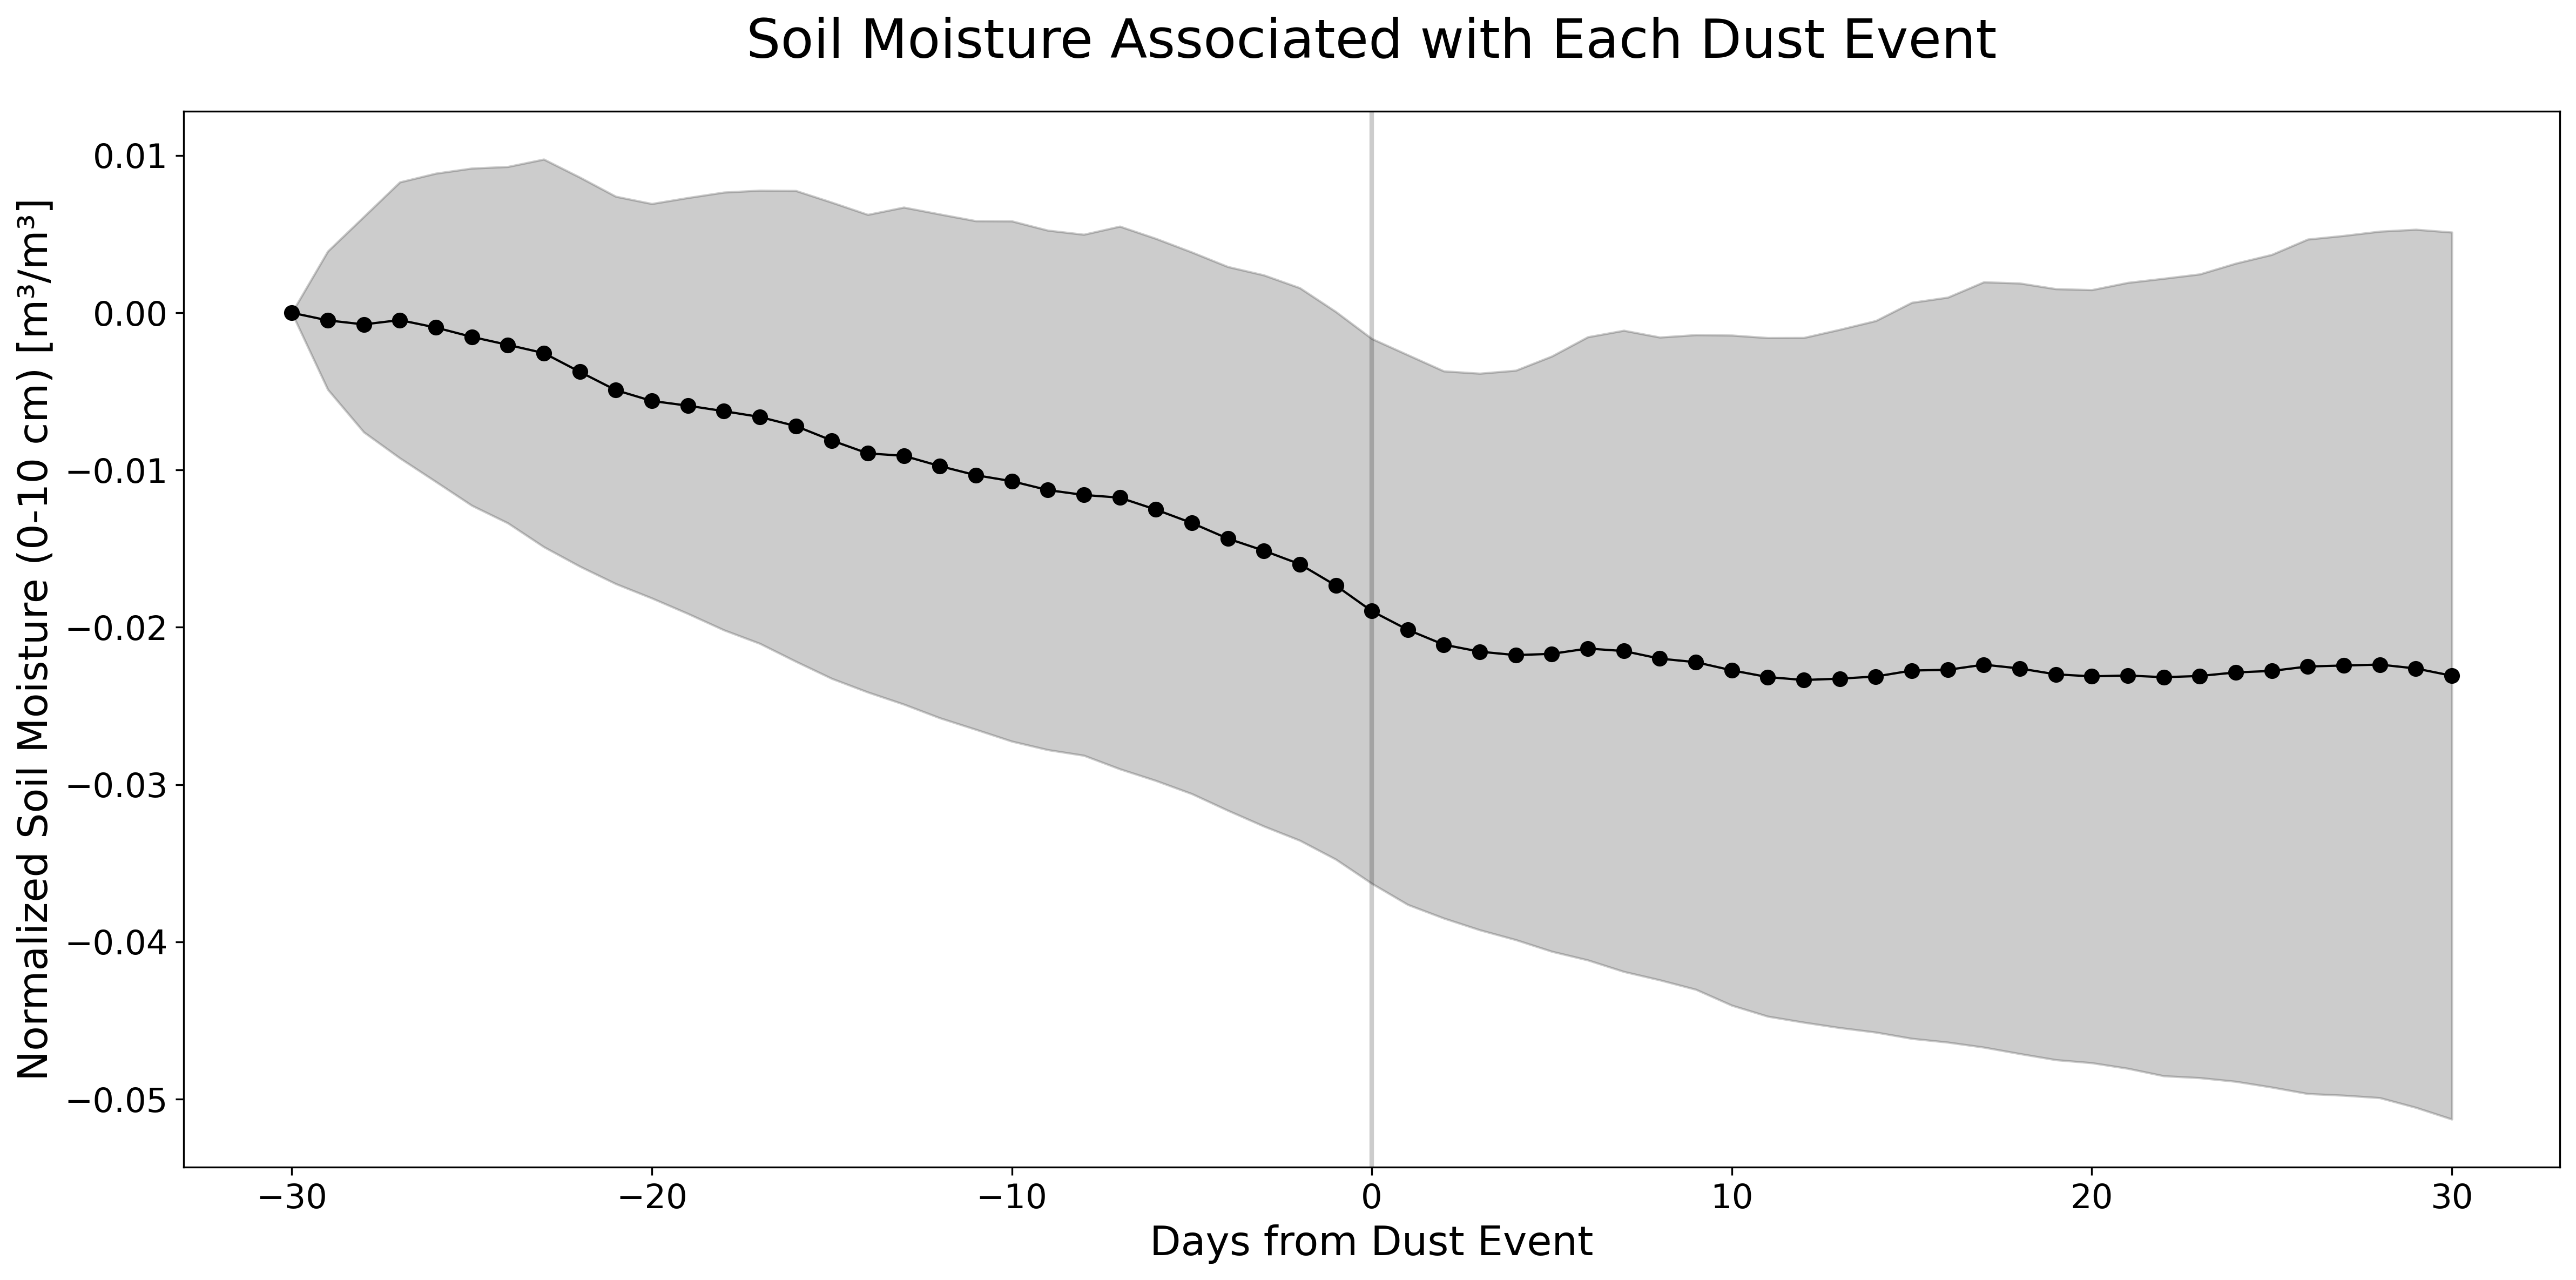

In [5]:
fig, ax = plt.subplots(figsize=(16, 8), dpi=300)

x = range(-30,31)

ax.plot(x, trend_mean, color='black', linewidth=1, marker='o')

ax.fill_between(x,
    trend_mean - trend_std/2,
    trend_mean + trend_std/2,
    color='black', alpha=0.2)

ax.axvline(x=0, color='black', linewidth=2, alpha=0.2)

ax.tick_params(axis='both', labelsize=15)
ax.set_ylabel("Normalized Soil Moisture (0-10 cm) [m³/m³]", fontsize=18)
ax.set_xlabel("Days from Dust Event", fontsize=18)
ax.set_title(f"Soil Moisture Associated with Each Dust Event", fontsize=24, pad=24)

plt.tight_layout()
plt.show()